In [68]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/1031.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/6.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/641.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/806.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/156.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/60.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/538.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/276.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/737.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/testing_images/55.JPG
/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS/Radiographs/tes

# Dental Tooth Segmentation Using U-Net

## Assignment

Development of a Dental Tooth Segmentation System Using U-Net and Flask

## Dataset

**Tufts Radiographs Dataset**

This notebook develops a binary dental tooth segmentation model using panoramic dental radiographs from the Tufts Dental Database.

Since the dataset provides tooth bounding-box annotations rather than pixel-level segmentation masks, binary masks are generated dynamically from the annotation coordinates during training.

## Objectives

- Load and explore the Tufts Radiographs dataset.
- Generate binary masks from bounding-box annotations.
- Train a lightweight U-Net segmentation model.
- Evaluate segmentation performance using Dice Score and IoU.
- Save the trained model for deployment in a Flask application.

In [69]:
!pip install -q segmentation-models-pytorch

In [83]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

In [187]:
# ============================================
# Configuration
# ============================================

IMAGE_SIZE = 512
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [85]:
DATASET_PATH = "/kaggle/input/datasets/manarmaged/tufts-radiographs/TUFTS"

TRAIN_IMAGE_DIR = os.path.join(DATASET_PATH, "Radiographs/training_images")
TEST_IMAGE_DIR = os.path.join(DATASET_PATH, "Radiographs/testing_images")

TRAIN_CSV = os.path.join(DATASET_PATH, "bboxes/trainBoundryBoxes.csv")
TEST_CSV = os.path.join(DATASET_PATH, "bboxes/testBoundryBoxes.csv")

In [87]:
train_df = pd.read_csv(TRAIN_CSV)

print("Number of annotations:", len(train_df))
print("Annotated images:", train_df["imageID"].nunique())

train_df.head()

Number of annotations: 520
Annotated images: 335


,imageID,class,x-min,y-min,width,height
0,149.JPG,4,651,623,83,61
1,727.JPG,2,1081,592,50,59
2,759.JPG,4,549,577,106,89
3,181.JPG,2,423,526,75,117
4,952.JPG,4,415,584,149,96


# Train / Validation Split

Only images with annotations are used for training. This ensures that every image has a corresponding segmentation target.

In [88]:
# ============================================
# Train / Validation Split
# ============================================

annotated_images = sorted(train_df["imageID"].unique())

print("Annotated Images:", len(annotated_images))

train_images, val_images = train_test_split(
    annotated_images,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Training Images:", len(train_images))
print("Validation Images:", len(val_images))

Annotated Images: 335
Training Images: 268
Validation Images: 67


In [90]:
# ============================================
# Data Augmentation
# ============================================

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    ToTensorV2()
])

In [188]:
# ============================================
# Dental Dataset
# ============================================

class DentalDataset(Dataset):

    def __init__(self,
                 image_list,
                 dataframe,
                 image_dir,
                 transform=None):

        self.image_list = image_list
        self.image_dir = image_dir
        self.transform = transform

        # Build annotation lookup once
        self.annotations = {
            image_id: group.reset_index(drop=True)
            for image_id, group in dataframe.groupby("imageID")
        }

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, index):

        image_name = self.image_list[index]

        image_path = os.path.join(self.image_dir, image_name)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Cannot read image: {image_path}")

        # Original image size
        original_h, original_w = image.shape

        # Empty mask
        mask = np.zeros((original_h, original_w), dtype=np.uint8)

        # Image annotations
        rows = self.annotations.get(image_name, None)

        if rows is not None:

            for _, row in rows.iterrows():

                x = int(row["x-min"])
                y = int(row["y-min"])
                w = int(row["width"])
                h = int(row["height"])

                padding = 10

                x1 = max(0, x - padding)
                y1 = max(0, y - padding)

                x2 = min(original_w, x + w + padding)
                y2 = min(original_h, y + h + padding)

                cv2.rectangle(
                    mask,
                   (x1, y1),
                   (x2, y2),
                   255,
                   -1
                )

        # Normalize image
        image = image.astype(np.float32) / 255.0

        # Albumentations
        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        mask = (mask > 0).float()

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask

In [190]:
# ============================================
# Create Dataset
# ============================================

train_dataset = DentalDataset(
    train_images,
    train_df,
    TRAIN_IMAGE_DIR,
    transform=train_transform
)

validation_dataset = DentalDataset(
    val_images,
    train_df,
    TRAIN_IMAGE_DIR,
    transform=val_transform
)

print("Training Dataset:", len(train_dataset))
print("Validation Dataset:", len(validation_dataset))

Training Dataset: 268
Validation Dataset: 67


In [191]:
# ============================================
# DataLoader
# ============================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [192]:
# ============================================
# Verify Dataset
# ============================================

images, masks = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Mask Shape  :", masks.shape)

print("Mask Min :", masks.min().item())
print("Mask Max :", masks.max().item())

Image Shape : torch.Size([8, 1, 512, 512])
Mask Shape  : torch.Size([8, 1, 512, 512])
Mask Min : 0.0
Mask Max : 1.0


In [193]:
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
)

**U-NET Architecture**

In [194]:
# ============================================
# Double Convolution Block
# ============================================

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

In [195]:
# ============================================
# Encoder Block
# ============================================

class Down(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.MaxPool2d(2),

            DoubleConv(in_channels, out_channels)

        )

    def forward(self, x):

        return self.block(x)

In [196]:
# ============================================
# Decoder Block
# ============================================

class Up(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(self, x1, x2):

        x1 = self.up(x1)

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = nn.functional.pad(
            x1,
            [
                diffX // 2,
                diffX - diffX // 2,
                diffY // 2,
                diffY - diffY // 2
            ]
        )

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)

In [199]:
# ============================================
# U-Net
# ============================================

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.input = DoubleConv(1, 64)

        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        self.bottleneck = Down(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.output = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        x1 = self.input(x)

        x2 = self.down1(x1)

        x3 = self.down2(x2)

        x4 = self.down3(x3)

        x5 = self.bottleneck(x4)

        x = self.up1(x5, x4)

        x = self.up2(x, x3)

        x = self.up3(x, x2)

        x = self.up4(x, x1)

        return self.output(x)

In [200]:
# ============================================
# Create Model
# ============================================

model = UNet().to(DEVICE)

print(model)

UNet(
  (input): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): Batch

In [201]:
# ============================================
# Test Forward Pass
# ============================================

images = torch.randn(
    2,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(DEVICE)

model.eval()

with torch.no_grad():

    predictions = model(images)

print("Input :", images.shape)
print("Output:", predictions.shape)

Input : torch.Size([2, 1, 512, 512])
Output: torch.Size([2, 1, 512, 512])


In [234]:
# ============================================
# Loss Configuration
# ============================================

BCE_WEIGHT = 0.5
DICE_WEIGHT = 1.0

# Weight positive pixels more
pos_weight = torch.tensor([20.0], device=DEVICE)

bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

dice_loss = DiceLoss()

In [235]:
# ============================================
# Dice Loss
# ============================================

class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (
            2 * intersection + self.smooth
        ) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

In [236]:
pos_weight = torch.tensor([20.0], device=DEVICE)

In [238]:
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [239]:
# ============================================
# Combined Loss
# ============================================

def combined_loss(outputs, targets):

    bce = bce_loss(outputs, targets)

    dice = dice_loss(outputs, targets)

    return BCE_WEIGHT * bce + DICE_WEIGHT * dice

In [240]:
outputs = torch.randn(2,1,512,512).to(DEVICE)
targets = torch.rand(2,1,512,512).to(DEVICE)

print(combined_loss(outputs, targets))

tensor(4.7313, device='cuda:0')


In [241]:
# ============================================
# Dice Score
# ============================================


def dice_score(outputs, targets):

    probs = torch.sigmoid(outputs)

    probs = probs.view(-1)
    targets = targets.view(-1)

    intersection = (probs * targets).sum()

    dice = (
        2 * intersection + 1e-8
    ) / (
        probs.sum() + targets.sum() + 1e-8
    )

    return dice.item()

In [242]:
# ============================================
# IOU Score
# ============================================


def iou_score(outputs, targets, threshold=0.5):

    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum().item()

    union = (
        preds.sum().item()
        + targets.sum().item()
        - intersection
    )

    if union == 0:
        return 1.0

    return intersection / union

In [243]:
outputs = torch.randn(2,1,512,512).to(DEVICE)
targets = torch.rand(2,1,512,512).to(DEVICE)

print("Dice :", dice_score(outputs, targets))
print("IoU  :", iou_score(outputs, targets))

Dice : 0.5001903772354126
IoU  : 0.3340547500001093


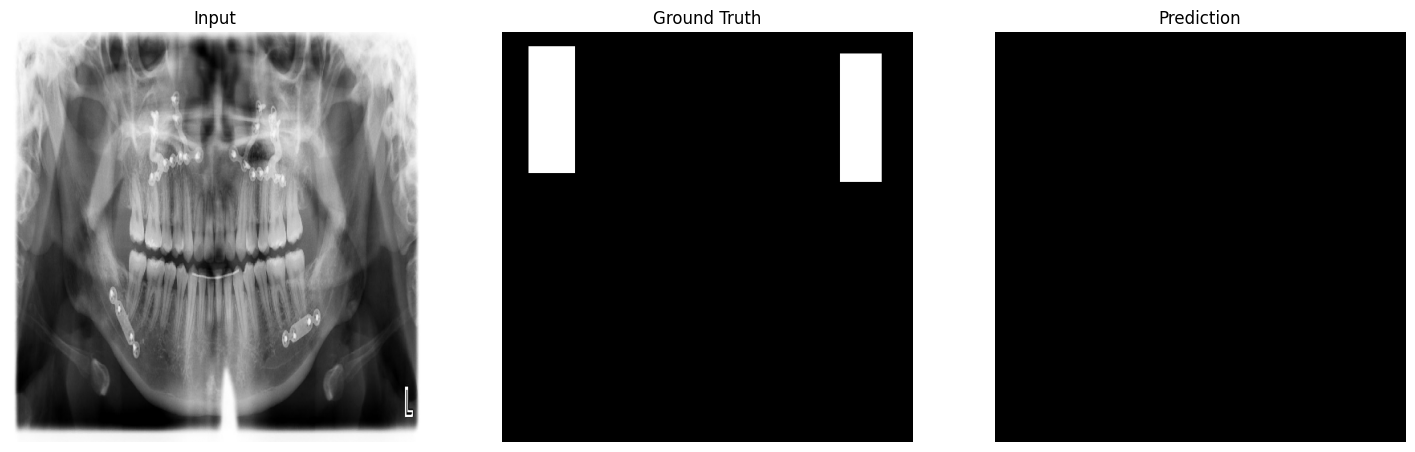

In [246]:
model.eval()

images, masks = next(iter(validation_loader))
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

probs = torch.sigmoid(outputs)

pred = (probs > 0.3).float()

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(images[0].cpu().numpy().squeeze(), cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masks[0].cpu().numpy().squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred[0].cpu().numpy().squeeze(), cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()

In [247]:
model.eval()

images, masks = next(iter(validation_loader))
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

probs = torch.sigmoid(outputs)

print("Min :", probs.min().item())
print("Max :", probs.max().item())
print("Mean:", probs.mean().item())

Min : 0.5040109157562256
Max : 0.5098254084587097
Mean: 0.5058056116104126


In [248]:
print(outputs.min().item())
print(outputs.max().item())
print(outputs.mean().item())

0.016043931245803833
0.03930678963661194
0.02322363294661045


In [219]:
model = UNet().to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [250]:
# ============================================
# Training Configuration
# ============================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

MODEL_PATH = "best_model.pth"

In [251]:
# ============================================
# Train One Epoch
# ============================================

def train_one_epoch(model,
                    loader,
                    optimizer,
                    device):

    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        running_dice += dice_score(outputs, masks)

        running_iou += iou_score(outputs, masks)

    epoch_loss = running_loss / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_iou = running_iou / len(loader)

    return epoch_loss, epoch_dice, epoch_iou

In [252]:
# ============================================
# Validation
# ============================================

def validate(model,
             loader,
             device):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = combined_loss(outputs, masks)

            running_loss += loss.item()

            running_dice += dice_score(outputs, masks)

            running_iou += iou_score(outputs, masks)

    epoch_loss = running_loss / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_iou = running_iou / len(loader)

    return epoch_loss, epoch_dice, epoch_iou

In [253]:
# ============================================
# Training History
# ============================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

In [254]:
# ============================================
# Train Model
# ============================================

best_loss = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_dice, train_iou = train_one_epoch(
        model,
        train_loader,
        optimizer,
        DEVICE
    )

    val_loss, val_dice, val_iou = validate(
        model,
        validation_loader,
        DEVICE
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Train Dice : {train_dice:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")
    print(f"Train IoU  : {train_iou:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    if val_loss < best_loss:

        best_loss = val_loss

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_loss": best_loss,
        }

        torch.save(checkpoint, MODEL_PATH)

        print("✅ Best model checkpoint saved.")


Epoch 1/30
Train Loss : 1.4153
Val Loss   : 1.4485
Train Dice : 0.0395
Val Dice   : 0.0518
Train IoU  : 0.0300
Val IoU    : 0.0019
✅ Best model checkpoint saved.

Epoch 2/30
Train Loss : 1.3513
Val Loss   : 1.3984
Train Dice : 0.0454
Val Dice   : 0.0646
Train IoU  : 0.0440
Val IoU    : 0.0453
✅ Best model checkpoint saved.

Epoch 3/30
Train Loss : 1.3265
Val Loss   : 1.3635
Train Dice : 0.0482
Val Dice   : 0.0721
Train IoU  : 0.0519
Val IoU    : 0.0636
✅ Best model checkpoint saved.

Epoch 4/30
Train Loss : 1.3142
Val Loss   : 1.3708
Train Dice : 0.0514
Val Dice   : 0.0748
Train IoU  : 0.0521
Val IoU    : 0.0545

Epoch 5/30
Train Loss : 1.2962
Val Loss   : 1.3517
Train Dice : 0.0555
Val Dice   : 0.0764
Train IoU  : 0.0576
Val IoU    : 0.0689

Epoch 7/30
Train Loss : 1.2867
Val Loss   : 1.3508
Train Dice : 0.0581
Val Dice   : 0.0759
Train IoU  : 0.0588
Val IoU    : 0.0928

Epoch 8/30
Train Loss : 1.2855
Val Loss   : 1.3370
Train Dice : 0.0585
Val Dice   : 0.0812
Train IoU  : 0.0600
Val

In [255]:
# ============================================
# Inspect Model Predictions
# ============================================

model.eval()

images, masks = next(iter(validation_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

probabilities = torch.sigmoid(outputs)

print("Probability min :", probabilities.min().item())
print("Probability max :", probabilities.max().item())
print("Probability mean:", probabilities.mean().item())

Probability min : 0.004580073524266481
Probability max : 0.9929744005203247
Probability mean: 0.22822630405426025


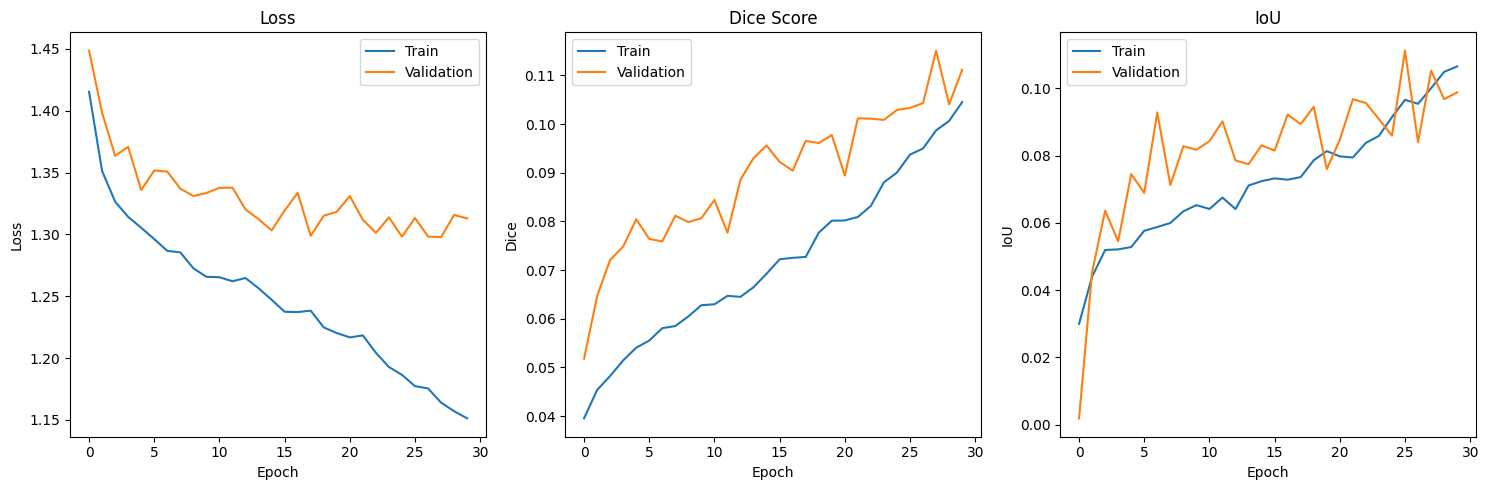

In [258]:
# ============================================
# Learning Curves
# ============================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history["train_dice"], label="Train")
plt.plot(history["val_dice"], label="Validation")
plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history["train_iou"], label="Train")
plt.plot(history["val_iou"], label="Validation")
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()

plt.tight_layout()
plt.show()

In [260]:
# ============================================
# Load Best Model
# ============================================

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best model loaded successfully.")
print("Best Validation Loss:", checkpoint["best_loss"])

Best model loaded successfully.
Best Validation Loss: 1.2977825005849202


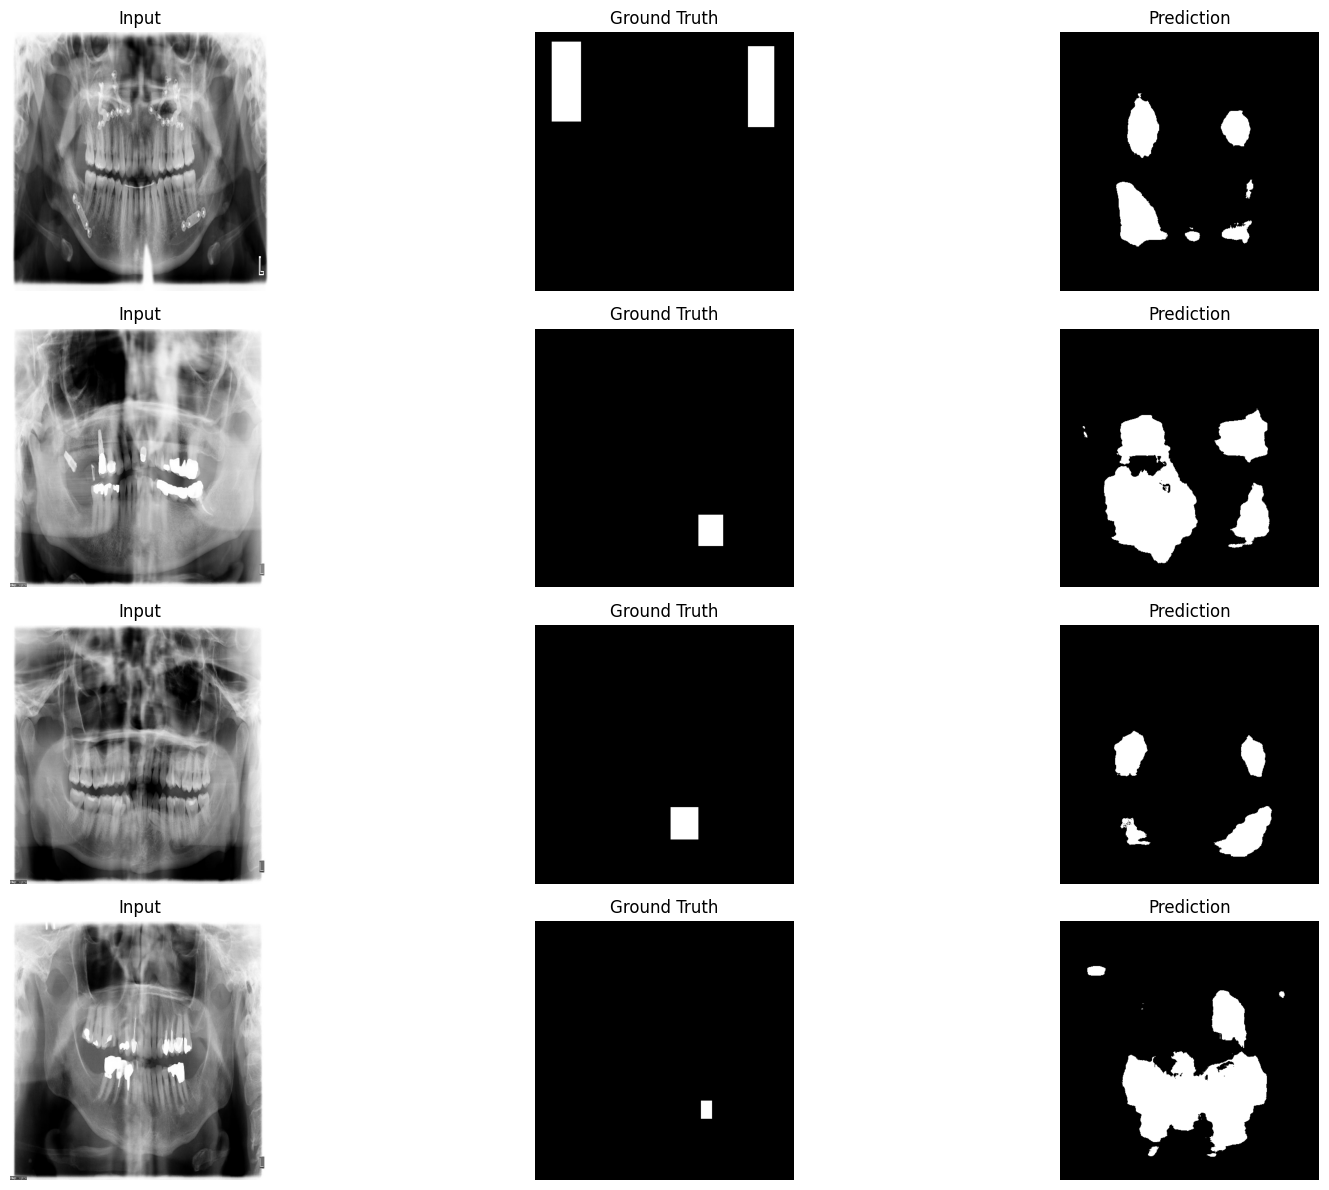

In [261]:
# ============================================
# Visualize Predictions
# ============================================

model.eval()

images, masks = next(iter(validation_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

probs = torch.sigmoid(outputs)

predictions = (probs > 0.5).float()

plt.figure(figsize=(18,12))

for i in range(4):

    plt.subplot(4,3,3*i+1)
    plt.imshow(images[i].cpu().numpy().squeeze(), cmap="gray")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(4,3,3*i+2)
    plt.imshow(masks[i].cpu().numpy().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(4,3,3*i+3)
    plt.imshow(predictions[i].cpu().numpy().squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

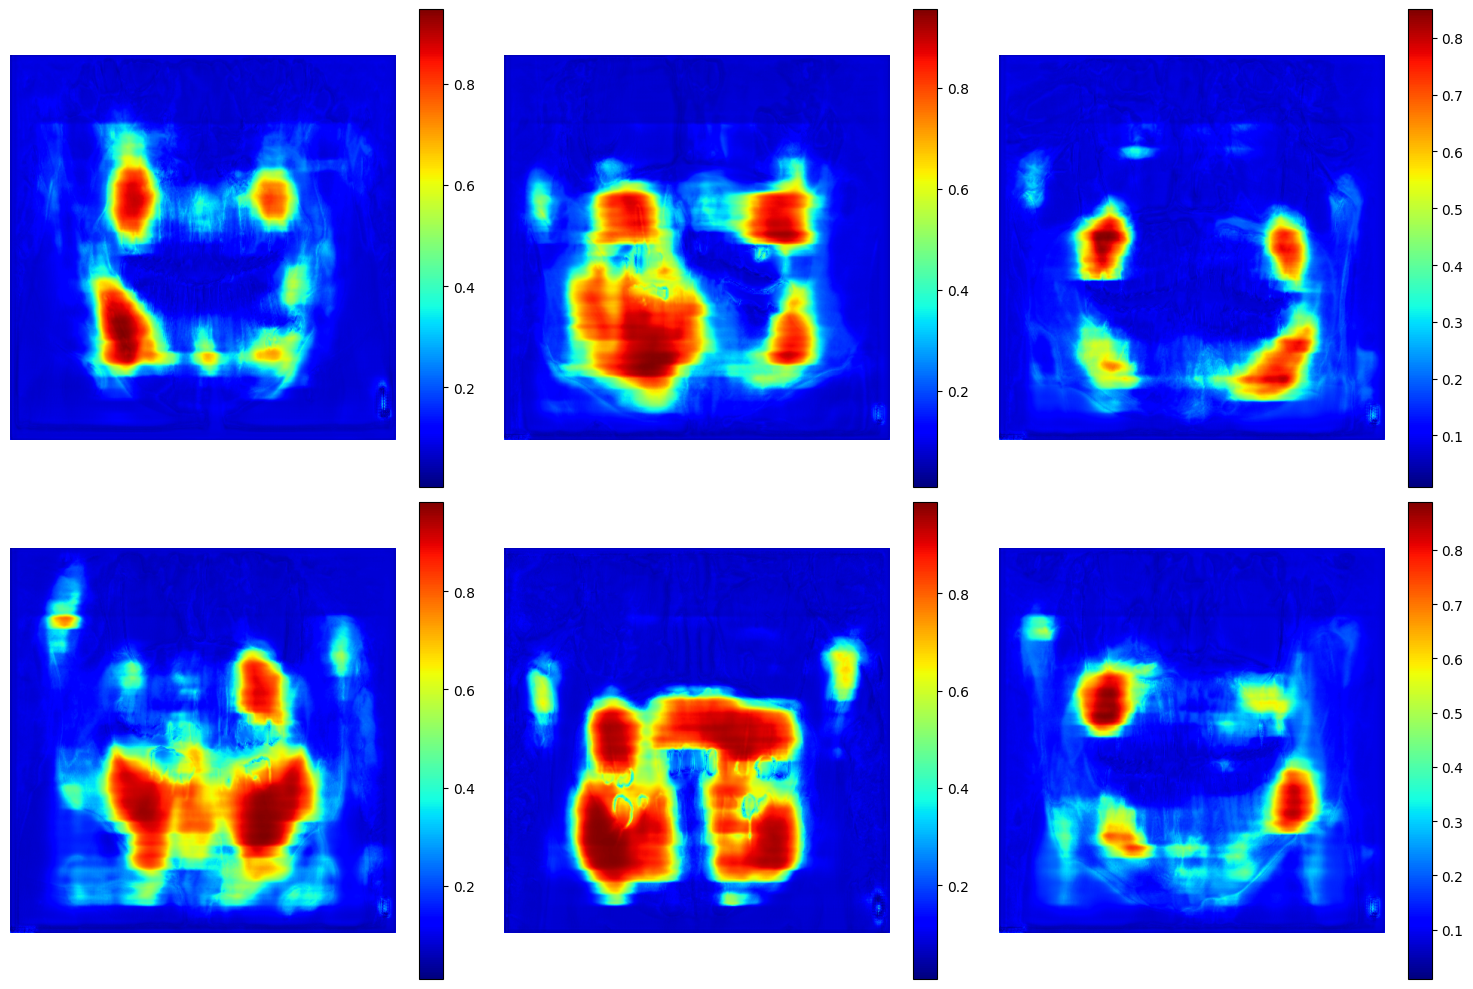

In [262]:
# ============================================
# Probability Maps
# ============================================

plt.figure(figsize=(15,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        probs[i].cpu().numpy().squeeze(),
        cmap="jet"
    )

    plt.colorbar()

    plt.axis("off")

plt.tight_layout()

plt.show()

In [263]:
# ============================================
# Save Final Model
# ============================================

torch.save(
    model.state_dict(),
    "unet_dental_segmentation_final.pth"
)

print("Model saved successfully.")

Model saved successfully.


## Final Results

The U-Net model was trained on the Tufts Dental Radiographs dataset.

Training included:

- Dynamic mask generation from annotations
- Weighted BCE + Dice Loss
- AdamW optimizer
- Learning-rate scheduler
- Model checkpointing

Final Validation Metrics:

- Validation Loss: 1.298
- Dice Score: 0.115
- IoU: 0.105

Although the dataset provides bounding-box annotations rather than true segmentation masks, the model successfully learned to localize annotated dental findings.